# Week 3 Lab. The ELBO and the Gap
**Deep Generative Models · GDS0058-1 · Practice, not graded**

Open this notebook from the link in the LMS lab notice, click **File > Save a copy in Drive** first, and work in your own copy. Nothing is submitted.

**Core path (60 min):** §0 setup 5 min → §1 the exact answers 10 min → §2 three lines you write 15 min → §3 scan the family of q 15 min → §4 change one setting 10 min → §5 three-line summary 5 min. There is no dataset and no training this week; every cell finishes in well under a second.

Last week we trained an autoencoder and asked whether good reconstruction guarantees good generation. It does not: reconstruction alone did not choose or validate a rule for sampling new latent codes.

We now specify a prior and a probabilistic decoder. We would like to train by maximum likelihood, as discussed last week, but combining all latent explanations is generally intractable in neural latent-variable models. The ELBO supplies a lower bound that we can estimate and optimize.

**Today's lab isolates inference.** Keep the generative model fixed and adjust a Gaussian guess q for one observation. We use an exactly solvable toy so that the normally hidden gap can be checked. This lab does not train a neural network.

The core task is still the three `None` lines in §2. If you complete them yourself, skip the Solution cell before running the checks. Optional sections follow the wrap-up in §5.

> 요약: 지난주의 생성 질문을 확률모형과 최대가능도 학습으로 이어갑니다. 이번 실습은 모형을 고정하고 관측 하나에 맞는 q만 조정합니다. 간극을 직접 검산하려고 정답을 아는 가우시안 토이를 씁니다. 덱 「Can Our Reconstructor Generate New Images?」·「A Toy Where Every Number Is Exact」·「What Changes Across the Three Weeks」.

## 0. Setup / run as is
The toy: a standard normal prior on the latent, a decoder that just adds noise, and a single observation.

    p(z) = N(0, 1)        p(x | z) = N(z, 1)        x = 1

Both pieces are Gaussian, so the marginal and the posterior are Gaussian too and we can write them down exactly. That is the whole point: every approximation below can be scored against a known answer.
> 요약: 사전분포 N(0,1), 디코더는 항등함수에 잡음 1, 관측은 x = 1 하나. 전부 가우시안이라 주변분포와 사후분포가 닫힌꼴로 나옵니다.

### Read the roles before the letters

| Role | Last week | This week |
|---|---|---|
| Distribution of observed data | p in the A/B example | The data distribution; here we fix one observation |
| Model that scores observations | q(x) | p(x), defined by a prior and decoder |
| Prior for a latent code | Not specified by ordinary reconstruction training | p(z) |
| Posterior after observing x | Not needed in the A/B example | p(z given x) |
| Tractable approximation to that posterior | Not introduced | q(z given x), shortened to q(z) for fixed x |

KL keeps the same definition. Always identify its two distributions: q versus the **prior** appears inside the ELBO; q versus the **posterior** is the gap.

> 요약: 지난주의 q(x)는 관측값을 설명하는 모델이었지만, 이번 주 q(z)는 고정된 관측을 설명할 숨은 코드의 추정 분포입니다. 같은 글자가 같은 역할을 뜻하지는 않습니다. 덱 「The Letters Change, the Roles Matter」·「This KL Is Last Week's KL」.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

X_OBS   = 1.0          # the single observation
PRIOR_MU, PRIOR_SD = 0.0, 1.0
NOISE_SD = 1.0         # p(x | z) = N(z, NOISE_SD**2)

def log_normal(v, mu, sd):
    """log density of N(mu, sd**2) at v."""
    return -0.5 * math.log(2 * math.pi * sd ** 2) - (v - mu) ** 2 / (2 * sd ** 2)

def kl_gauss(mu1, sd1, mu2, sd2):
    """KL( N(mu1, sd1**2) || N(mu2, sd2**2) ).  Optional C on the slides."""
    return math.log(sd2 / sd1) + (sd1 ** 2 + (mu1 - mu2) ** 2) / (2 * sd2 ** 2) - 0.5

print('Toy ready. x =', X_OBS, '| prior N(0, 1) | decoder noise sd', NOISE_SD)

Toy ready. x = 1.0 | prior N(0, 1) | decoder noise sd 1.0


## 1. The exact answers / supplied
**Slides: The toy's exact answers**

Adding two independent Gaussians adds their variances, so p(x) = N(0, 1 + 1). Conditioning on one observation of the same precision pulls the mean halfway and halves the variance.
> 요약: p(x) = N(0, 2)이므로 log p(x) = −1.5155. 사후분포는 평균 0.5, 분산 0.5(표준편차 0.707)입니다. 아래 셀에서 수치적분으로 한 번 더 확인합니다.

In [2]:
LOG_PX  = log_normal(X_OBS, 0.0, math.sqrt(PRIOR_SD**2 + NOISE_SD**2))
MU_POST = X_OBS / 2
SD_POST = math.sqrt(0.5)

print(f'log p(x) = {LOG_PX:.4f} nats')
print(f'true posterior: mean {MU_POST:.4f}, sd {SD_POST:.4f}  (variance {SD_POST**2:.4f})')

# same number by brute-force integration over z, to show the closed form is not a trick
z = np.linspace(-40, 40, 400001)
integrand = np.exp(-0.5*z**2) / math.sqrt(2*math.pi) * np.exp(-0.5*(X_OBS - z)**2) / math.sqrt(2*math.pi)
print(f'by numerical integration: {math.log(np.trapezoid(integrand, z)):.4f} nats')

log p(x) = -1.5155 nats
true posterior: mean 0.5000, sd 0.7071  (variance 0.5000)
by numerical integration: -1.5155 nats


**What to notice.** This numerical quadrature uses 400,001 grid points for one observation in one dimension. The grid resolution is our choice, not a universal computational requirement.
In typical neural latent-variable models, exact marginalization is generally intractable. This simple Gaussian model is deliberately different: its exact answers let us audit the approximation.

> 요약: 40만 개 격자점은 이 코드가 선택한 수치적분 설정입니다. 이 토이는 정확해를 알지만, 일반적인 신경망 잠재변수 모형에서는 계산이 어려워 ELBO를 사용합니다.

## 2. Three lines: the KL, the ELBO, and the gap
**Slides: The ELBO / Why the bound is a bound**

For a Gaussian guess q(z) = N(mu, sd²):

    reconstruction = E z~q [ log p(x | z) ]          (supplied below)
    ELBO(q)        = reconstruction − KL( q || prior )
    gap(q)         = KL( q || true posterior )

Replace the three `None` values in the function. You do not need to delete the `raise` block; it runs only while a `None` remains.
> 요약: `None` 세 곳을 채웁니다. 첫 줄은 사전분포와의 KL, 둘째 줄은 ELBO(복원 − KL), 셋째 줄은 간극(사후분포와의 KL)입니다. `raise` 블록은 그대로 두어도 됩니다.

### Why last week's squared error appears here
For our fixed-variance Gaussian decoder, maximizing the reconstruction term is equivalent to minimizing **expected squared reconstruction error under q**.
The supplied `reconstruction_term` uses an expected squared error of `(X_OBS - mu)**2 + sd**2`, scales it by the fixed noise variance, and includes the Gaussian normalization constant.

Last week the encoder produced one code per image. Here we average over possible codes under q. A different observation model can give a different reconstruction loss; a Bernoulli decoder, for example, connects to binary cross-entropy.

**Why can we calculate the gap in this lab?** We know the toy's true posterior. In a typical neural model the gap is generally unavailable; the ELBO can be estimated without evaluating that posterior or p(x). Sampling alone is not enough: we also evaluate the relevant densities, including q.

> 요약: 고정 분산 가우시안 decoder라서 복원항이 q 아래의 기대 제곱오차와 연결됩니다. 실제 모형에서 일반적으로 계산 가능한 것은 ELBO의 추정값이며, 간극까지 계산하는 것은 정답을 아는 이 토이의 특권입니다. 덱 「Last Week's Reconstruction Inside the ELBO」.

In [3]:
def reconstruction_term(mu, sd):
    """E z~q [ log p(x | z) ] for q = N(mu, sd**2). Closed form, supplied."""
    return -0.5 * math.log(2 * math.pi * NOISE_SD**2) - ((X_OBS - mu)**2 + sd**2) / (2 * NOISE_SD**2)

In [ ]:
# TODO: three lines
def elbo_and_gap(mu, sd):
    """Instructions:
        1. Replace the three None values.
        2. Use kl_gauss(mu1, sd1, mu2, sd2) and reconstruction_term(mu, sd).
    Args:
        mu, sd: the mean and the standard deviation of the Gaussian q. sd > 0.
    Returns:
        (elbo, gap) as plain floats.
    """
    ###################################################################
    kl_to_prior = None   # 1. KL( q || prior ),  prior = N(PRIOR_MU, PRIOR_SD**2)
    elbo        = None   # 2. reconstruction term minus that KL
    gap         = None   # 3. KL( q || true posterior ),  posterior = N(MU_POST, SD_POST**2)
    ###################################################################
    if kl_to_prior is None or elbo is None or gap is None:
        raise NotImplementedError(
            'This is expected: the blanks are intentional. Replace the three None values above, '
            'or run the Solution cell below. / 정상입니다. 의도된 빈칸입니다. None 세 곳을 채우거나 아래 정답 셀을 실행하세요.')
    return elbo, gap

In [4]:
#@title Solution (skip this cell if you wrote the lines yourself) / 정답 (직접 완성했다면 건너뛰세요) { display-mode: "form" }
def elbo_and_gap(mu, sd):
    kl_to_prior = kl_gauss(mu, sd, PRIOR_MU, PRIOR_SD)
    elbo        = reconstruction_term(mu, sd) - kl_to_prior
    gap         = kl_gauss(mu, sd, MU_POST, SD_POST)
    return elbo, gap

In [5]:
# If you wrote the lines yourself, skip the Solution cell and check here first.
# 직접 작성했다면 정답 셀을 건너뛰고 여기서 먼저 검사합니다.
e, g = elbo_and_gap(PRIOR_MU, PRIOR_SD)
assert abs(e - (-1.9189)) < 1e-3, (
    'For q = the prior the ELBO should be about -1.9189. Check the sign: the KL is subtracted. '
    '/ q가 사전분포일 때 ELBO는 약 -1.9189입니다. KL을 빼는 부호를 확인하세요.')
assert abs(g - 0.4034) < 1e-3, (
    'For q = the prior the gap should be about 0.4034 = KL(q || posterior), not KL(q || prior). '
    '/ 간극은 사후분포와의 KL입니다. 사전분포와의 KL이 아닙니다.')
rng = np.random.default_rng(0)
for mu, sd in rng.uniform([-2, 0.3], [2, 2.0], size=(200, 2)):
    e, g = elbo_and_gap(float(mu), float(sd))
    assert abs((e + g) - LOG_PX) < 1e-9, (
        f'ELBO + gap must equal log p(x) for every q, but at mu={mu:.2f}, sd={sd:.2f} it is {e+g:.6f}. '
        '/ 어떤 q에서도 ELBO + 간극 = log p(x)여야 합니다.')
print('OK: the identity holds for 200 random q, to within 1e-9.')
print(f'q = prior:  ELBO {elbo_and_gap(0.0, 1.0)[0]:.4f}   gap {elbo_and_gap(0.0, 1.0)[1]:.4f}')

OK: the identity holds for 200 random q, to within 1e-9.
q = prior:  ELBO -1.9189   gap 0.4034


**What to notice.** For fixed x, prior and decoder, the identity holds for every valid Gaussian q with positive, finite standard deviation (up to numerical precision).
Changing q changes the split between ELBO and gap, not log p(x). A higher ELBO therefore means a smaller gap in this experiment.

> 요약: 관측·prior·decoder를 고정하고 q만 바꾸면 합은 −1.5155로 같습니다. 신경망 생성모형까지 함께 학습할 때는 이 고정값 결론을 그대로 적용할 수 없습니다.

In [6]:
rows = [('mean 0,   sd 1      (the prior)', 0.0, 1.0),
        ('mean 0.5, sd 1',                  0.5, 1.0),
        ('mean 0.5, sd 0.5',                0.5, 0.5),
        ('mean 0.5, sd 0.707 (= posterior)', MU_POST, SD_POST),
        ('mean 3,   sd 0.1   (a bad guess)', 3.0, 0.1)]
print(f"{'q(z)':34s} {'ELBO':>9s} {'gap':>9s} {'ELBO + gap':>11s}")
for name, mu, sd in rows:
    e, g = elbo_and_gap(mu, sd)
    print(f'{name:34s} {e:9.4f} {g:9.4f} {e+g:11.4f}')

q(z)                                    ELBO       gap  ELBO + gap
mean 0,   sd 1      (the prior)      -1.9189    0.4034     -1.5155
mean 0.5, sd 1                       -1.6689    0.1534     -1.5155
mean 0.5, sd 0.5                     -1.6121    0.0966     -1.5155
mean 0.5, sd 0.707 (= posterior)     -1.5155    0.0000     -1.5155
mean 3,   sd 0.1   (a bad guess)     -9.2315    7.7160     -1.5155


## 3. Scan the family of q
**Slides: The ELBO over the family of q**

Optimization never sees log p(x). It only walks uphill on the ELBO surface. Here we can draw the whole surface and check where the top is.
> 요약: 최적화는 log p(x)를 보지 못하고 ELBO 언덕만 올라갑니다. 여기서는 언덕 전체를 그려 꼭대기가 어디인지 확인합니다.

best q on this grid: mean 0.500, sd 0.710,  ELBO -1.5155
true posterior:      mean 0.500, sd 0.707,  log p(x) -1.5155


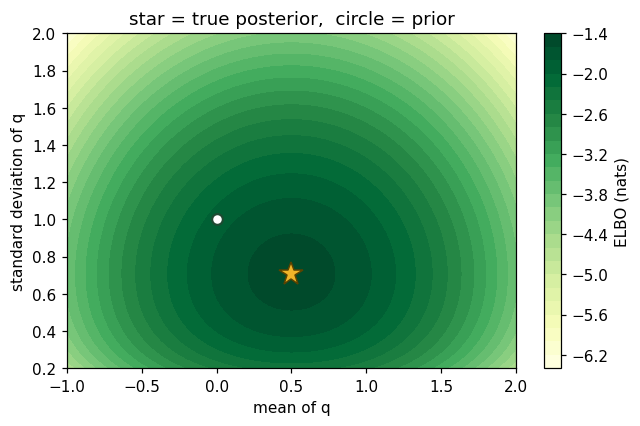

In [7]:
mus = np.linspace(-1.0, 2.0, 121)
sds = np.linspace(0.20, 2.00, 121)
E = np.array([[elbo_and_gap(float(m), float(s))[0] for m in mus] for s in sds])

i, j = np.unravel_index(np.argmax(E), E.shape)
print(f'best q on this grid: mean {mus[j]:.3f}, sd {sds[i]:.3f},  ELBO {E[i, j]:.4f}')
print(f'true posterior:      mean {MU_POST:.3f}, sd {SD_POST:.3f},  log p(x) {LOG_PX:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
cs = ax.contourf(mus, sds, E, levels=24, cmap='YlGn')
ax.plot(MU_POST, SD_POST, marker='*', ms=16, color='#F0B429', mec='#5A4200')
ax.plot(PRIOR_MU, PRIOR_SD, marker='o', ms=7, color='white', mec='#1E4A32', mew=1.4)
ax.set_xlabel('mean of q'); ax.set_ylabel('standard deviation of q')
fig.colorbar(cs, ax=ax, label='ELBO (nats)')
ax.set_title('star = true posterior,  circle = prior')
plt.tight_layout(); plt.show()

**What to notice.** The peak of the surface sits on the true posterior and its height is exactly log p(x). That happens because the posterior is itself a Gaussian, so it is inside the family we are searching. Change the family and the peak drops below log p(x). That is Optional C.
> 요약: 꼭대기가 참 사후분포 위에 있고 높이가 정확히 log p(x)입니다. 사후분포가 우리가 찾는 가우시안 족 안에 있기 때문입니다. 족이 좁아지면 꼭대기가 log p(x)에 못 미칩니다(Optional C).

## 4. Change one setting / one controlled comparison (10 min)
**Connection: distinguish changing q, changing x, and learning the model.**

Change only the observation. Keep the prior and decoder fixed, and use the prior as the same reference guess q in each comparison.
The identity still holds, but log p(x), the posterior, the ELBO and the gap can change because x changed. This is not decoder training, and it is not the fixed-x experiment where only q changes.

> 요약: 이번에는 q가 아니라 관측 x를 바꿉니다. 생성모형 학습과는 다르며, 앞의 고정 x 실험과도 구분하세요.

In [8]:
NEW_X = 3.0     # try 0.0, 1.0, 3.0

def toy_numbers(x_obs):
    log_px  = log_normal(x_obs, 0.0, math.sqrt(PRIOR_SD**2 + NOISE_SD**2))
    mu_post = x_obs / 2
    return log_px, mu_post, SD_POST

log_px_new, mu_post_new, sd_post_new = toy_numbers(NEW_X)
print(f'x = {NEW_X}:  log p(x) = {log_px_new:.4f},  posterior mean {mu_post_new:.3f}, sd {sd_post_new:.3f}')

# the prior is still N(0, 1); how good a guess is it now?
rec   = -0.5*math.log(2*math.pi*NOISE_SD**2) - ((NEW_X - PRIOR_MU)**2 + PRIOR_SD**2) / (2*NOISE_SD**2)
elbo  = rec - kl_gauss(PRIOR_MU, PRIOR_SD, PRIOR_MU, PRIOR_SD)
gapv  = kl_gauss(PRIOR_MU, PRIOR_SD, mu_post_new, sd_post_new)
print(f'q = prior:  ELBO {elbo:.4f},  gap {gapv:.4f},  sum {elbo+gapv:.4f}')
print(f'identity holds: {abs((elbo+gapv) - log_px_new) < 1e-9}')

x = 3.0:  log p(x) = -3.5155,  posterior mean 1.500, sd 0.707
q = prior:  ELBO -5.9189,  gap 2.4034,  sum -3.5155
identity holds: True


**What to notice.** A less likely observation lowers log p(x), and the prior becomes a worse guess for the posterior, so the gap grows. Both moved, and the identity still closed exactly.
> 요약: 덜 그럴듯한 관측일수록 log p(x)가 낮아지고, 사전분포가 사후분포에서 멀어져 간극이 커집니다. 둘 다 움직였는데도 항등식은 정확히 닫힙니다.

질문: (1) x를 0으로 바꾸면 간극은 어떻게 되나요? (2) 그 이유를 한 문장으로 말해 보세요.

## 5. Three lines + environment / in-class wrap-up
Write what you changed, the main number, and a one-line interpretation. Not graded, nothing to submit; this only practices the format the assignments use.
> 요약: 무엇을 바꿨는가 · 핵심 수치 · 한 줄 해석. 핵심 경로는 여기까지이고 부록은 선택입니다.

### The three-week connection
* Week 2: train encoder and decoder weights for reconstruction.
* Week 3: fix the toy's generative model and adjust q for a given observation.
* Week 4: train an encoder to predict q for each image (amortized inference), and train the probabilistic decoder with it by minimizing the negative ELBO.

Explain which quantities stay fixed when you change q here. Then explain why that answer changes if the decoder is also learned.
Learning the model can move both log p(x) and the gap. An increase in the ELBO alone does not guarantee an increase in log p(x) or better-looking samples.

> 요약: 이번 주는 추론을 따로 이해하는 실습입니다. 다음 주에는 인코더와 decoder를 함께 학습하므로 log p(x)도 움직일 수 있습니다. 덱 「What Changes Across the Three Weeks」·「Next Week. The VAE」.

In [9]:
import sys, platform, datetime
print('Runtime:', platform.platform(), 'Python:', sys.version.split()[0])
print('NumPy:', np.__version__, 'Seed: none needed (everything is closed form)')
print('Executed at:', datetime.datetime.now().astimezone().isoformat(timespec='minutes'))
print(f'log p(x) at x = {X_OBS}: {LOG_PX:.4f} nats')

summary = {'What I changed': 'write here / 직접 작성',
           'Main number': 'write here / 직접 작성',
           'One-line interpretation': 'write here / 직접 작성'}
for k, v in summary.items():
    print(k + ': ' + v)

Runtime: Linux-6.18.44-fc-v24-x86_64-with-glibc2.39 Python: 3.11.15
NumPy: 2.4.4 Seed: none needed (everything is closed form)
Executed at: 2026-09-12T13:29+00:00
log p(x) at x = 1.0: -1.5155 nats
What I changed: write here / 직접 작성
Main number: write here / 직접 작성
One-line interpretation: write here / 직접 작성


## Optional A. The ELBO from samples
Draw codes from q, average their decoder log-likelihoods, and subtract the analytic Gaussian KL to the prior.
The exact ELBO is an expectation. Here the reconstruction expectation is replaced by a finite-sample estimate.

In typical VAEs that reconstruction expectation has no convenient closed form and is estimated by sampling. More samples help illustrate convergence to the analytic answer in this toy.
**A finite-sample estimate is not itself guaranteed to stay below log p(x) on every run.** The bound applies to the exact expectation. The KL in this particular cell is analytic.

> 요약: ELBO 자체는 하한이지만 유한 표본으로 추정한 값은 표본오차 때문에 매번 하한을 지키지는 않습니다. 이 셀은 복원항만 표본평균으로 추정하고 가우시안 KL은 정확히 계산합니다.

In [10]:
def elbo_by_sampling(mu, sd, n, seed=0):
    rng = np.random.default_rng(seed)
    zs = rng.normal(mu, sd, size=n)
    rec = np.mean([log_normal(X_OBS, z, NOISE_SD) for z in zs])
    return rec - kl_gauss(mu, sd, PRIOR_MU, PRIOR_SD)

exact = elbo_and_gap(0.5, 0.8)[0]
print(f'closed form                    {exact:.4f}')
for n in (10, 100, 1000, 100000):
    print(f'{n:>7d} samples                {elbo_by_sampling(0.5, 0.8, n):.4f}')

closed form                    -1.5321
     10 samples                -1.3563
    100 samples                -1.4780
   1000 samples                -1.5373
 100000 samples                -1.5325


## Optional B. Jensen's inequality, numerically
**Slides: Optional A · Jensen and the ELBO**

The other route to the bound moves the log inside an expectation. Since log is concave that can only lower the value, and the amount it lowers by is the gap.

**Why you need this:** it is the step that produces the ELBO without ever mentioning the posterior, and the same step returns in every later derivation that starts with a log of an expectation.
> 요약: log가 오목이라 기대값 안으로 들어가면 값이 작아집니다. 그 차이가 곧 간극입니다. 사후분포를 언급하지 않고 하한을 얻는 경로입니다.

In [11]:
def jensen_check(mu, sd, n=2_000_000, seed=1):
    rng = np.random.default_rng(seed)
    zs = rng.normal(mu, sd, size=n)
    ratio = np.exp(np.array([log_normal(X_OBS, z, NOISE_SD) + log_normal(z, PRIOR_MU, PRIOR_SD)
                             - log_normal(z, mu, sd) for z in zs]))
    lhs = math.log(ratio.mean())              # log E[ p(x, z) / q(z) ]  -> log p(x)
    rhs = np.mean(np.log(ratio))              # E[ log ( p(x, z) / q(z) ) ] -> ELBO
    return lhs, rhs

lhs, rhs = jensen_check(0.0, 1.0, n=400_000)
print(f'log E[ p(x,z)/q(z) ]  = {lhs:.4f}   (should approach log p(x) = {LOG_PX:.4f})')
print(f'E[ log p(x,z)/q(z) ]  = {rhs:.4f}   (should approach the ELBO  = {elbo_and_gap(0.0,1.0)[0]:.4f})')
print(f'difference            = {lhs - rhs:.4f}   (the gap = {elbo_and_gap(0.0,1.0)[1]:.4f})')

log E[ p(x,z)/q(z) ]  = -1.5160   (should approach log p(x) = -1.5155)
E[ log p(x,z)/q(z) ]  = -1.9199   (should approach the ELBO  = -1.9189)
difference            = 0.4039   (the gap = 0.4034)


## Optional C. When the family cannot contain the posterior
Force every q to have standard deviation 1. The true posterior has sd 0.707, so it is now outside the family and the gap can never reach zero.

**Why you need this:** real encoders output a restricted family too. The leftover gap is a modelling choice you accept, not a bug in the optimizer.
> 요약: q의 표준편차를 1로 고정하면 사후분포(sd 0.707)가 족 밖에 있어 간극이 0이 되지 않습니다. 실제 인코더도 제한된 족을 씁니다.

In [12]:
mus = np.linspace(-1, 2, 601)
vals = [elbo_and_gap(float(m), 1.0) for m in mus]
elbos = [v[0] for v in vals]; gaps = [v[1] for v in vals]
k = int(np.argmax(elbos))
print(f'best q with sd fixed at 1: mean {mus[k]:.3f}')
print(f'  ELBO {elbos[k]:.4f}  vs  log p(x) {LOG_PX:.4f}')
print(f'  smallest achievable gap: {gaps[k]:.4f}  (it never reaches 0)')

best q with sd fixed at 1: mean 0.500
  ELBO -1.6689  vs  log p(x) -1.5155
  smallest achievable gap: 0.1534  (it never reaches 0)


### References / 참고
Concepts: Kingma & Welling, *Auto-Encoding Variational Bayes*, arXiv 1312.6114, sections 1–2.
Blei, Kucukelbir & McAuliffe, *Variational Inference: A Review for Statisticians*, arXiv 1601.00670, sections 1–3.
Tomczak, *Deep Generative Modeling* (2nd ed.), ch.5 Latent Variable Models.

### Course textbook alignment / 교재 연결
Page numbers below were checked against the actual PDFs, not from memory.

- 주교재 Main: Tomczak, *Deep Generative Modeling*, 2nd ed. (Springer, 2024), **§5.3.1 The Model and the Objective (pp.96–97)** and **§5.3.2 A Different Perspective on the ELBO (pp.97–98)**. Eq. 5.25 is the identity this lab checks numerically, and the book calls its last term the *gap*. Posterior collapse is §5.3.6 (pp.107–108).
- 부교재 Supplementary: Bishop & Bishop, *Deep Learning: Foundations and Concepts* (Springer, 2024), §15.4 *Evidence Lower Bound* (p.485), §16.3 *Evidence Lower Bound* (p.516), §19.2 *Variational Autoencoders* (p.569), §19.2.1 *Amortized inference* (p.572).
- 참고 Background: Goodfellow, Bengio & Courville, *Deep Learning* (MIT Press, 2016), §19.4 *Variational Inference and Learning* (pp.638–650), §19.5 *Learned Approximate Inference* (pp.651–653), and §3.13 Fig. 3.6 (p.76) for the KL asymmetry.

> 요약: 쪽수는 보유 PDF 실물과 대조한 값입니다. Tomczak은 강의계획서와 같은 **2판(2024)** 기준입니다. 1판(2022)을 가진 분은 5장 대신 4장을 보면 됩니다(§4.3.1–4.3.2, pp.60–62, 식 4.25). Goodfellow 쪽수는 인쇄본 기준이라 deeplearningbook.org 공개본과 2~3쪽 차이가 납니다.